In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Veriyi yükle
df = pd.read_csv("temiz_veri/birlesik_veri.csv", index_col='datetime', parse_dates=True)

# Prophet ds (tarih) ve y (hedef) sütunları ister
df_prophet = df[['Global_active_power']].reset_index()
df_prophet.columns = ['ds', 'y']

print("Veri boyutu:", df_prophet.shape)
print("İlk 3 satır:")
df_prophet.head(3)

Importing plotly failed. Interactive plots will not work.


Veri boyutu: (34168, 2)
İlk 3 satır:


,ds,y
0,2006-12-16 17:00:00,4.222889
1,2006-12-16 18:00:00,3.632200
2,2006-12-16 19:00:00,3.400233


In [2]:
bolme_tarihi = '2010-01-01'

egitim = df_prophet[df_prophet['ds'] < bolme_tarihi]
test = df_prophet[df_prophet['ds'] >= bolme_tarihi]

print(f"Eğitim: {len(egitim):,} satır")
print(f"Test:   {len(test):,} satır")

Eğitim: 26,541 satır
Test:   7,627 satır


In [3]:
mlflow.set_experiment("enerji_tahmin_prophet")

deney_parametreleri = [
    {"changepoint_prior_scale": 0.01, "seasonality_prior_scale": 10},
    {"changepoint_prior_scale": 0.1,  "seasonality_prior_scale": 10},
    {"changepoint_prior_scale": 0.5,  "seasonality_prior_scale": 15},
]

sonuclar = []

for i, params in enumerate(deney_parametreleri):
    print(f"\nDeney {i+1}/3 çalışıyor...")
    
    with mlflow.start_run(run_name=f"prophet_deney_{i+1}"):
        # Parametreleri kaydet
        mlflow.log_params(params)
        
        # Model oluştur ve eğit
        model = Prophet(
            changepoint_prior_scale=params["changepoint_prior_scale"],
            seasonality_prior_scale=params["seasonality_prior_scale"],
            yearly_seasonality=True,
            weekly_seasonality=True,
            daily_seasonality=True
        )
        model.fit(egitim)
        
        # Tahmin yap
        gelecek = model.make_future_dataframe(periods=len(test), freq='h')
        tahmin = model.predict(gelecek)
        
        # Test dönemi tahminlerini al
        test_tahmin = tahmin[tahmin['ds'] >= bolme_tarihi]['yhat'].values[:len(test)]
        test_gercek = test['y'].values[:len(test_tahmin)]
        
        # Metrikleri hesapla
        mae = mean_absolute_error(test_gercek, test_tahmin)
        rmse = np.sqrt(mean_squared_error(test_gercek, test_tahmin))
        r2 = r2_score(test_gercek, test_tahmin)
        
        # MLflow'a kaydet
        mlflow.log_metric("mae", mae)
        mlflow.log_metric("rmse", rmse)
        mlflow.log_metric("r2", r2)
        
        sonuclar.append({
            "deney": i+1,
            "changepoint": params["changepoint_prior_scale"],
            "seasonality": params["seasonality_prior_scale"],
            "mae": round(mae, 4),
            "rmse": round(rmse, 4),
            "r2": round(r2, 4)
        })
        
        print(f"  MAE: {mae:.4f} | RMSE: {rmse:.4f} | R²: {r2:.4f}")

print("\n✅ Tüm deneyler tamamlandı!")

2026/07/02 00:38:33 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/02 00:38:33 INFO mlflow.store.db.utils: Updating database tables
2026/07/02 00:38:35 INFO mlflow.tracking.fluent: Experiment with name 'enerji_tahmin_prophet' does not exist. Creating a new experiment.



Deney 1/3 çalışıyor...


00:38:39 - cmdstanpy - INFO - Chain [1] start processing
00:38:45 - cmdstanpy - INFO - Chain [1] done processing


  MAE: 0.6476 | RMSE: 0.8396 | R²: -0.1525

Deney 2/3 çalışıyor...


00:38:53 - cmdstanpy - INFO - Chain [1] start processing
00:39:02 - cmdstanpy - INFO - Chain [1] done processing


  MAE: 0.6689 | RMSE: 0.8912 | R²: -0.2985

Deney 3/3 çalışıyor...


00:39:08 - cmdstanpy - INFO - Chain [1] start processing
00:39:24 - cmdstanpy - INFO - Chain [1] done processing


  MAE: 0.7362 | RMSE: 0.9748 | R²: -0.5537

✅ Tüm deneyler tamamlandı!


In [4]:
df_sonuc = pd.DataFrame(sonuclar)
print("\n" + "="*55)
print("DENEY KARŞILAŞTIRMASI")
print("="*55)
print(df_sonuc.to_string(index=False))
print("="*55)
print(f"\nEn iyi R²: Deney {df_sonuc.loc[df_sonuc['r2'].idxmax(), 'deney']}")
print(f"En düşük MAE: Deney {df_sonuc.loc[df_sonuc['mae'].idxmin(), 'deney']}")


DENEY KARŞILAŞTIRMASI
 deney  changepoint  seasonality    mae   rmse      r2
     1         0.01           10 0.6476 0.8396 -0.1525
     2         0.10           10 0.6689 0.8912 -0.2985
     3         0.50           15 0.7362 0.9748 -0.5537

En iyi R²: Deney 1
En düşük MAE: Deney 1


00:40:56 - cmdstanpy - INFO - Chain [1] start processing
00:41:00 - cmdstanpy - INFO - Chain [1] done processing


Model kaydedildi ✅


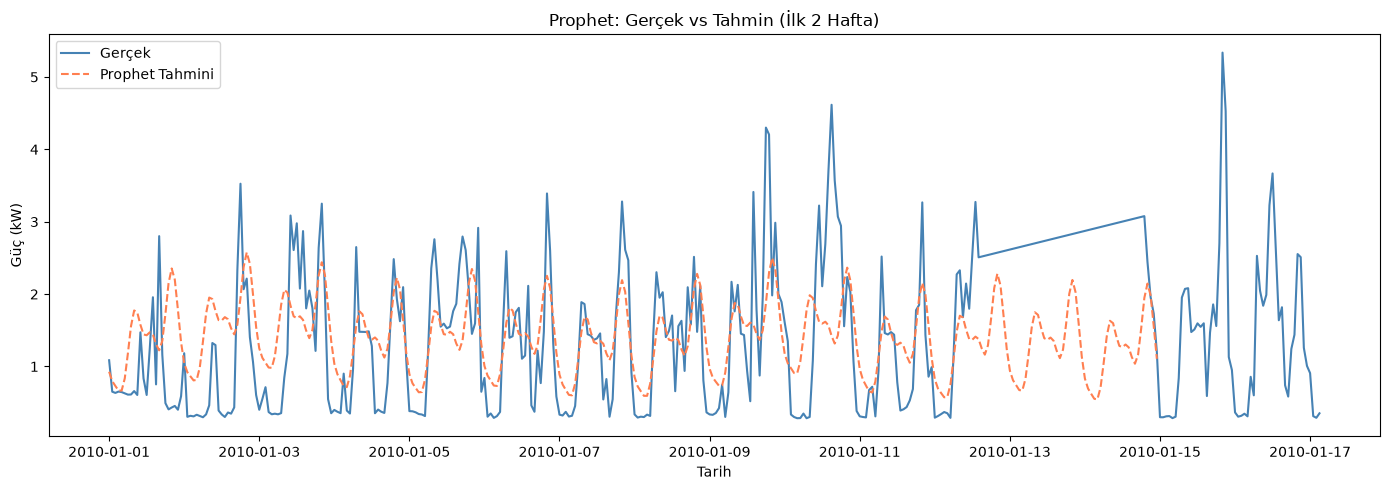

In [5]:
# En iyi model (Deney 1) ile tekrar çalıştır ve kaydet
with mlflow.start_run(run_name="prophet_en_iyi_model"):
    model_final = Prophet(
        changepoint_prior_scale=0.01,
        seasonality_prior_scale=10,
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=True
    )
    model_final.fit(egitim)
    
    gelecek = model_final.make_future_dataframe(periods=len(test), freq='h')
    tahmin = model_final.predict(gelecek)
    
    # MLflow'a kaydet
    mlflow.log_params({"changepoint_prior_scale": 0.01, "seasonality_prior_scale": 10})
    mlflow.log_param("model_turu", "prophet_final")
    
    import pickle, os
    os.makedirs("model", exist_ok=True)
    with open("model/prophet_model.pkl", "wb") as f:
        pickle.dump(model_final, f)
    mlflow.log_artifact("model/prophet_model.pkl")
    
    print("Model kaydedildi ✅")

# Grafik
test_tahmin = tahmin[tahmin['ds'] >= bolme_tarihi]

fig, ax = plt.subplots(figsize=(14, 5))
goster = 24 * 14  # İlk 2 hafta

ax.plot(test['ds'].values[:goster], test['y'].values[:goster],
        label='Gerçek', color='steelblue', linewidth=1.5)
ax.plot(test_tahmin['ds'].values[:goster], test_tahmin['yhat'].values[:goster],
        label='Prophet Tahmini', color='coral', linewidth=1.5, linestyle='--')

ax.set_title('Prophet: Gerçek vs Tahmin (İlk 2 Hafta)')
ax.set_ylabel('Güç (kW)')
ax.set_xlabel('Tarih')
ax.legend()
plt.tight_layout()
plt.show()